In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data/framingham.csv")
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [6]:
report = pd.DataFrame({
    "Data Type": df.dtypes,
    "Non-Null Count": df.notnull().sum(),
    "Null Count": df.isnull().sum(),
    "Unique Values": df.nunique(),
    "Duplicate Rows": [df.duplicated().sum()] * len(df.columns)  # Same for all columns
})

print(report)

df.dropna(axis=0, inplace=True)

                Data Type  Non-Null Count  Null Count  Unique Values  \
male                int64            3658           0              2   
age                 int64            3658           0             39   
education         float64            3658           0              4   
currentSmoker       int64            3658           0              2   
cigsPerDay        float64            3658           0             33   
BPMeds            float64            3658           0              2   
prevalentStroke     int64            3658           0              2   
prevalentHyp        int64            3658           0              2   
diabetes            int64            3658           0              2   
totChol           float64            3658           0            241   
sysBP             float64            3658           0            231   
diaBP             float64            3658           0            142   
BMI               float64            3658           0           

In [10]:
# Handling null values
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
df_imputed = imputer.fit_transform(df)

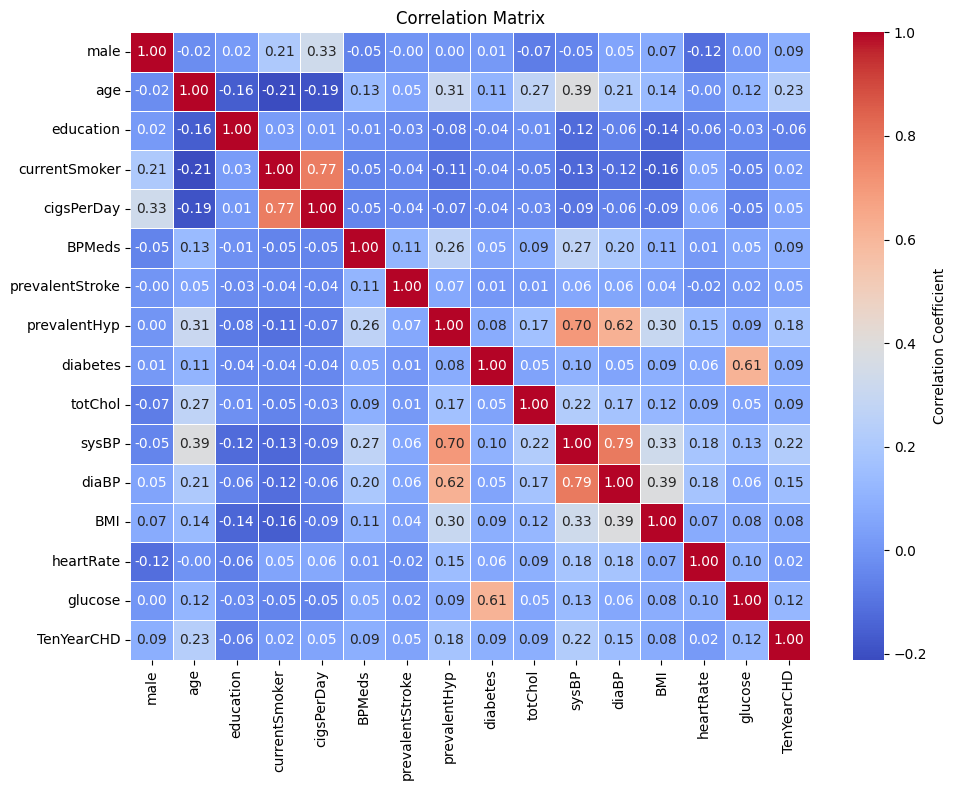

In [8]:
correlation_matrix = df.corr()

# Creating heatmap of correlation matrix
plt.figure(figsize=(10,8))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar_kws={'label': 'Correlation Coefficient'})
# Add title
plt.title('Correlation Matrix')

plt.tight_layout()

<Axes: title={'center': 'Distribution of age in dataset'}, ylabel='Frequency'>

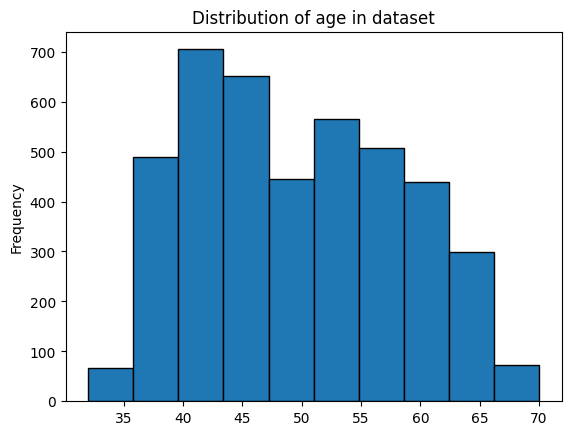

In [20]:
df['age'].plot(kind='hist', bins=10, title="Distribution of age in dataset", edgecolor='black')

<Axes: title={'center': 'Distribution of CHD in dataset'}, ylabel='Frequency'>

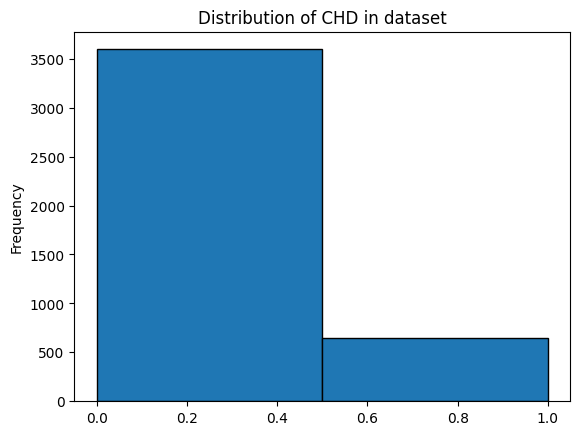

In [21]:
df['TenYearCHD'].plot(kind='hist', bins=2, title="Distribution of CHD in dataset", edgecolor='black')

In [31]:
import numpy as np
from sklearn import preprocessing
X = df[['age','cigsPerDay', 'sysBP', 'totChol', 'glucose']].to_numpy()
y = df['TenYearCHD'].to_numpy()

# normalize dataset
X = preprocessing.StandardScaler().fit(X).transform(X)

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.3, random_state = 4)

print('Train set:', X_train.shape, y_train.shape)

Train set: (2560, 5) (2560,)


In [39]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
prediction = model.predict(X_test)

In [40]:
from sklearn.metrics import accuracy_score
print('Model accuracy ', accuracy_score(y_test, prediction))

Model accuracy  0.8451730418943534
